In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER
import cftime
import datetime
from datetime import date
from matplotlib import pyplot
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import numpy
import pandas
import xarray as xr

In [2]:
# Define Directories
Diri = '../ExtraTrack_Data/Output_Files_V7/'
Output_Diri = '../RCP_Figs/Analysis_Figs_V7.4.2/'

In [3]:
# Open File
def Open_File(File):
    DF = pandas.read_csv(File)
    DF = DF.drop("Unnamed: 0", axis=1)
    return (DF)

In [4]:
# Open Each File
def Files_Open(Model, Diri, Subset):
    Data_DF = Open_File(Diri+Model+'_Data_'+Subset+'_Output.csv')
    ET_DF = Open_File(Diri+Model+'_ET_'+Subset+'_Output.csv')
    Codes_DF = Open_File(Diri+Model+'_Codes_Output.csv')
# Edit Time Format
    Time_Cols = ["ET Begin Time", "ET Complete Time", "Trop Peak Time", "Peak Time", "Genesis Time", "Final Time"]
    for Col in Time_Cols:
        ET_DF[Col] = pandas.to_datetime(ET_DF[Col], errors="coerce")
    Data_DF["Time(Z)"] = pandas.to_datetime(Data_DF["Time(Z)"], errors="coerce")
    return (Data_DF, ET_DF, Codes_DF)

In [5]:
# Create Phase Distribution Bins
def Create_Bins(Min, Max, Bin_Width):
    Bins = numpy.arange(Min, Max+Bin_Width, Bin_Width)
    return (Bins)

In [6]:
# Number of Years For Each Climate Scenario
Num_Years = numpy.array([90,93,93])

In [7]:
# Find distance between two points
def Find_Distance(y1, y2, x1, x2):
    Start_Lat = y1 * numpy.pi / 180
    End_Lat = y2 * numpy.pi / 180
    Start_Lon = x1 * numpy.pi / 180
    End_Lon = x2 * numpy.pi / 180
    Lat_Diff = End_Lat - Start_Lat
    Lon_Diff = End_Lon - Start_Lon
    Earth_Rad = 6378
    Distance = 2 * Earth_Rad * numpy.sqrt((numpy.sin(Lat_Diff/2))**2 + \
    numpy.cos(Start_Lat) * numpy.cos(End_Lat) * (numpy.sin(Lon_Diff/2))**2)
    return (Distance)

In [8]:
# Find a specific storm within the dataframe
def Find_Storm(DF, Code):
    DF_Storm = DF[DF["Code"] == Code].reset_index(drop=True)
    return (DF_Storm)

In [9]:
Control_Data, Control_ET, Control_Codes = Files_Open("Control", Diri, "SubsetB")
RCP45_Data, RCP45_ET, RCP45_Codes = Files_Open("RCP45", Diri, "SubsetB")
RCP85_Data, RCP85_ET, RCP85_Codes = Files_Open("RCP85", Diri, "SubsetB")

In [10]:
# Calculate Storm Translation Velocity
def Find_Velocity(DF_Storm):
    Lon_Diff = numpy.zeros(len(DF_Storm))
    Lat_Diff = numpy.zeros(len(DF_Storm))
    for i in range(len(DF_Storm)):
        if i < len(DF_Storm)-1:
            Lon_Diff[i] = DF_Storm["Lon"][i+1] - DF_Storm["Lon"][i]
            Lat_Diff[i] = DF_Storm["Lat"][i+1] - DF_Storm["Lat"][i]
        else:
            Lon_Diff[i], Lat_Diff[i] = numpy.nan, numpy.nan
    DF_Storm["Lon Diff"] = Lon_Diff
    DF_Storm["Lat Diff"] = Lat_Diff
    return (DF_Storm)

In [11]:
DF_Storm = Find_Storm(RCP45_Data, "TC200705")
Find_Velocity(DF_Storm)

,index,Code,Name,Lon,Lat,SLP(hPa),Winds(m/s),Dist(m),Angle,B,VLT,VUT,Time(Z),Storm Phase,Lon Diff,Lat Diff
0,623,TC200705,Demi,-44.40,35.31,1003.87,19.8,21.96,0.93,14.74,27.67,-45.11,2007-10-10 12:00:00,Tropical,0.00,0.20
1,624,TC200705,Demi,-44.40,35.51,1002.84,20.2,21.96,0.93,12.93,22.51,-48.16,2007-10-10 18:00:00,Tropical,0.01,0.20
2,625,TC200705,Demi,-44.39,35.71,1001.81,20.6,21.96,0.92,9.36,26.71,-45.35,2007-10-11 00:00:00,Tropical,0.00,0.20
3,626,TC200705,Demi,-44.39,35.91,1000.78,21.0,21.96,0.92,7.39,30.72,-32.51,2007-10-11 06:00:00,Tropical,0.36,-0.67
4,627,TC200705,Demi,-44.03,35.24,1001.63,18.4,80.96,156.03,4.53,37.46,-23.70,2007-10-11 12:00:00,Tropical,1.19,-0.40
5,628,TC200705,Demi,-42.84,34.84,1002.50,18.1,117.22,112.04,4.65,33.79,-20.72,2007-10-11 18:00:00,Tropical,1.20,-0.39
6,629,TC200705,Demi,-41.64,34.45,1003.36,17.7,117.71,111.95,7.99,32.50,-16.00,2007-10-12 00:00:00,Tropical,1.23,0.03
7,630,TC200705,Demi,-40.41,34.48,1003.23,18.3,112.86,88.02,11.00,39.78,-13.00,2007-10-12 06:00:00,Tropical,1.17,0.14
8,631,TC200705,Demi,-39.24,34.62,1004.00,22.1,108.90,81.77,7.68,44.53,-9.78,2007-10-12 12:00:00,Tropical,0.47,-0.07
9,632,TC200705,Demi,-38.77,34.55,1002.86,24.7,43.74,100.67,7.93,44.13,-1.09,2007-10-12 18:00:00,Tropical,-0.39,-1.22


In [12]:
# Create New DF With Translation Velocity Info
def Velocity_DF(DF, Codes):
    for i in range(len(Codes)):
        DF_Storm = Find_Storm(DF, Codes["New Code"][i])
        DF_Storm = Find_Velocity(DF_Storm)
        if i == 0:
            DF_Velocity = DF_Storm.copy()
        else:
            DF_Velocity = pandas.concat([DF_Velocity, DF_Storm])
    DF_Velocity = DF_Velocity.reset_index(drop=True)
    return (DF_Velocity)

In [13]:
Control_Velo = Velocity_DF(Control_Data, Control_Codes)

In [14]:
RCP45_Velo = Velocity_DF(RCP45_Data, RCP45_Codes)

In [15]:
RCP85_Velo = Velocity_DF(RCP85_Data, RCP85_Codes)

In [16]:
# Create DF of Each Latitude Range
def Lat_Range(Velo_DF, Min, Max):
    Range_DF = Velo_DF[(Velo_DF["Lat"] >= Min) & (Velo_DF["Lat"] < Max)]
    Range_DF = Range_DF[Range_DF["Lon Diff"] < 728].reset_index(drop=True)
    return (Range_DF)

In [ ]:
# Create Latitude Bins


In [17]:
# Calculate Mean Zonal and Meridional Velocity Within Each Latitude Range
def Lat_Range_DF(Velo_DF, Lats):
    Count = numpy.zeros(len(Lats))
    Lon_Velo_Mean = numpy.zeros(len(Lats))
    Lat_Velo_Mean = numpy.zeros(len(Lats))
    for i in range(len(Lats)):
        Range_DF = Lat_Range(Velo_DF, Lats[i]-2.5, Lats[i]+2.5)
        Count[i] = len(Range_DF)
        Lon_Velo_Mean[i] = numpy.mean(Range_DF["Lon Diff"]) / 6
        Lat_Velo_Mean[i] = numpy.mean(Range_DF["Lat Diff"]) / 6
    return (Count, Lon_Velo_Mean, Lat_Velo_Mean)

In [18]:
# Create DF to Store Mean Zonal and Meridional Velocity Within Each Latitude Range
def Lon_Lat_Velo(Control_Velo, RCP45_Velo, RCP85_Velo):
    Lats = Create_Bins(10,52.5,0.5)
    Control_Count, Control_Lon_Velo, Control_Lat_Velo = Lat_Range_DF(Control_Velo, Lats)
    RCP45_Count, RCP45_Lon_Velo, RCP45_Lat_Velo = Lat_Range_DF(RCP45_Velo, Lats)
    RCP85_Count, RCP85_Lon_Velo, RCP85_Lat_Velo = Lat_Range_DF(RCP85_Velo, Lats)
    Velo_DF = pandas.DataFrame({"Lat": Lats, \
    "Control Count": Control_Count, "Control Lon Velo": Control_Lon_Velo, "Control Lat Velo": Control_Lat_Velo, \
    "RCP4.5 Count": RCP45_Count, "RCP4.5 Lon Velo": RCP45_Lon_Velo, "RCP4.5 Lat Velo": RCP45_Lat_Velo, \
    "RCP8.5 Count": RCP85_Count, "RCP8.5 Lon Velo": RCP85_Lon_Velo, "RCP8.5 Lat Velo": RCP85_Lat_Velo})
    return (Velo_DF)

In [19]:
# Create Velocity DF
Velo_DF = Lon_Lat_Velo(Control_Velo, RCP45_Velo, RCP85_Velo)

In [20]:
# Create Velocity DF With Every 2.5 Degrees Latitude
Velo_DF_2 = Velo_DF[Velo_DF["Lat"] % 2.5 == 0].reset_index(drop=True)
Velo_DF_2

,index,Lat,Control Count,Control Lon Velo,Control Lat Velo,RCP4.5 Count,RCP4.5 Lon Velo,RCP4.5 Lat Velo,RCP8.5 Count,RCP8.5 Lon Velo,RCP8.5 Lat Velo
0,0,10.0,510.0,-0.164301,0.051696,270.0,-0.161630,0.071451,157.0,-0.136083,0.080913
1,5,12.5,1243.0,-0.188379,0.050036,645.0,-0.180450,0.058809,464.0,-0.172841,0.064960
2,10,15.0,1687.0,-0.187469,0.054710,977.0,-0.190838,0.058427,959.0,-0.187795,0.047847
3,15,17.5,1610.0,-0.166138,0.068532,1025.0,-0.188137,0.069169,1006.0,-0.176662,0.055673
4,20,20.0,1505.0,-0.131093,0.083424,907.0,-0.157253,0.086646,762.0,-0.135440,0.084729
5,25,22.5,1632.0,-0.081800,0.085935,879.0,-0.103039,0.094850,837.0,-0.076408,0.089484
6,30,25.0,1870.0,-0.029990,0.085212,928.0,-0.050855,0.099743,936.0,-0.020655,0.093992
7,35,27.5,1891.0,0.013632,0.094659,1085.0,0.004934,0.098155,1072.0,0.030771,0.095382
8,40,30.0,1875.0,0.042924,0.103395,1313.0,0.044614,0.090420,1341.0,0.069710,0.088523
9,45,32.5,1851.0,0.081453,0.110826,1442.0,0.079539,0.091096,1409.0,0.115305,0.096427


In [21]:
# Plot Zonal Velocity at Each Latitude
def Plot_Lon_Velo(Axis, Velo_DF):
    Axis.plot(Velo_DF["Control Lon Velo"], Velo_DF["Lat"], c='limegreen', linewidth=1.8, label='Control')
    Axis.plot(Velo_DF["RCP4.5 Lon Velo"], Velo_DF["Lat"], c='darkorange', linewidth=1.8, label='RCP4.5')
    Axis.plot(Velo_DF["RCP8.5 Lon Velo"], Velo_DF["Lat"], c='red', linewidth=1.8, label='RCP8.5')
# Formatting
    pyplot.xlim(-0.3,0.5)
    pyplot.xticks(Create_Bins(-0.3,0.5,0.1))
    pyplot.ylim(10,57.5)
    pyplot.yticks(Create_Bins(10,52.5,2.5))
    pyplot.xlabel("Zonal Velocity (°/hr)", fontsize=16)
    pyplot.ylabel("Latitude", fontsize=16)
    pyplot.title("Average Zonal Velocity VS Latitude", fontsize=20)
    Axis.grid(linewidth=0.5, color='silver', linestyle='-')

In [27]:
# Plot Meridional Velocity at Each Latitude
def Plot_Lat_Velo(Axis, Velo_DF):
    Axis.plot(Velo_DF["Control Lat Velo"], Velo_DF["Lat"], c='limegreen', linewidth=1.8, label='Control')
    Axis.plot(Velo_DF["RCP4.5 Lat Velo"], Velo_DF["Lat"], c='darkorange', linewidth=1.8, label='RCP4.5')
    Axis.plot(Velo_DF["RCP8.5 Lat Velo"], Velo_DF["Lat"], c='red', linewidth=1.8, label='RCP8.5')
# Formatting
    pyplot.xlim(0.02,0.18)
    pyplot.xticks(Create_Bins(0.02,0.24,0.02))
    pyplot.ylim(10,57.5)
    pyplot.yticks(Create_Bins(10,52.5,2.5))
    pyplot.xlabel("Meridional Velocity (°/hr)", fontsize=16)
    pyplot.title("Average Meridional Velocity VS Latitude", fontsize=20)
    Axis.grid(linewidth=0.5, color='silver', linestyle='-')
# Legend
    pyplot.legend(loc=2, fontsize=15)

In [23]:
# Plot Vectors of Translation Motion For Each Latitude
def Plot_Vectors(Axis, Velo_DF):
    Vector_Plotting(Velo_DF, "Control Lon Velo", "Control Lat Velo", 'limegreen', "Control")
    Vector_Plotting(Velo_DF, "RCP4.5 Lon Velo", "RCP4.5 Lat Velo", 'darkorange', "RCP4.5")
    Vector_Plotting(Velo_DF, "RCP8.5 Lon Velo", "RCP8.5 Lat Velo", 'red', "RCP8.5")
    pyplot.xlim(-0.03,0.03)
    pyplot.ylim(10,57.5)
    pyplot.yticks(Create_Bins(10,52.5,2.5))
    pyplot.title("Average Motion Vector VS Latitude", fontsize=20)
    Axis.grid(linewidth=0.5, color='silver', linestyle='-')

In [24]:
# Plot Vectors of Translation Motion
def Vector_Plotting(Velo_DF, Lon_Velo, Lat_Velo, Colour, Label):
    Zeros = numpy.zeros(len(Velo_DF["Lat"]))
    pyplot.quiver(Zeros, Velo_DF["Lat"], Velo_DF[Lon_Velo], Velo_DF[Lat_Velo], color=Colour, label=Label, \
    scale=1, width=0.005)

In [25]:
# Define Bins
Lat_Bins = Create_Bins(10,52.5,5)
Lon_Bins = Create_Bins(-100,20,5)

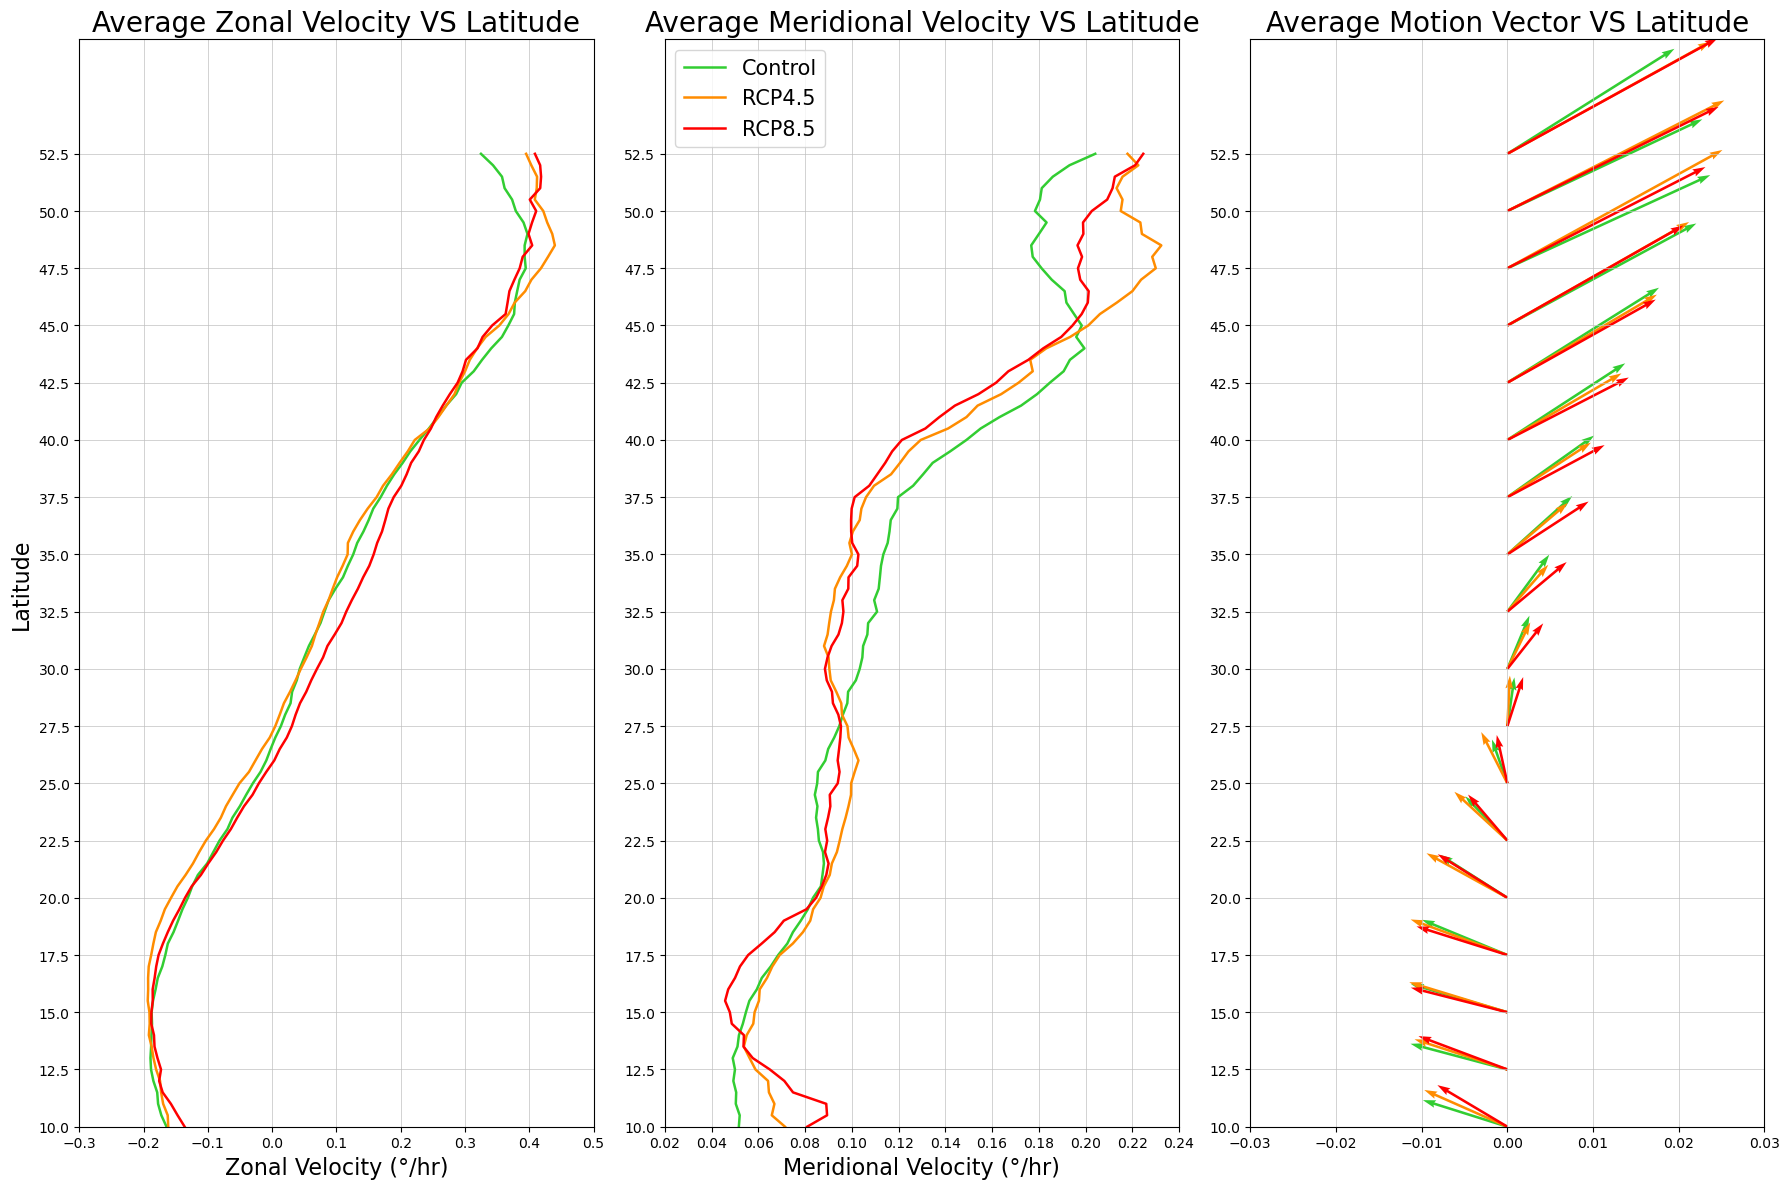

In [28]:
# Create Figure
Fig = pyplot.figure(figsize=(18,12))
#
# Plot Zonal Velocity
Ax1 = Fig.add_subplot(1,3,1)
Plot_Lon_Velo(Ax1, Velo_DF)
#
# Plot Meridional Velocity
Ax2 = Fig.add_subplot(1,3,2)
Plot_Lat_Velo(Ax2, Velo_DF)
#
# Plot Vectors
Ax3 = Fig.add_subplot(1,3,3)
Plot_Vectors(Ax3, Velo_DF_2)
#
# Savefig
pyplot.tight_layout()
Fig.savefig(Output_Diri+'Motion_Vectors.png', bbox_inches='tight')